N= 2, τ=0.7796, Eb=1.382011, Ergotropy=0.975025, erg/Eb=0.705511845452 Variance=4.9325495235e-02
N= 3, τ=0.6353, Eb=2.007871, Ergotropy=1.670310, erg/Eb=0.831881168474 Variance=5.5071783233e-01
N= 4, τ=0.5526, Eb=2.654379, Ergotropy=2.181179, erg/Eb=0.821728550261 Variance=1.0302274202e+00
N= 5, τ=0.4967, Eb=3.310403, Ergotropy=2.816834, erg/Eb=0.850903556824 Variance=4.3013674150e-01
N= 6, τ=0.4556, Eb=3.973193, Ergotropy=3.486086, erg/Eb=0.877401565338 Variance=8.4795543659e-01
N= 7, τ=0.4236, Eb=4.640189, Ergotropy=4.078929, erg/Eb=0.879043627864 Variance=1.2073855048e+00
N= 8, τ=0.3977, Eb=5.309960, Ergotropy=4.744798, erg/Eb=0.893565626784 Variance=6.9545160805e-01
N= 9, τ=0.3763, Eb=5.984043, Ergotropy=5.421540, erg/Eb=0.905999516769 Variance=1.0518036771e+00


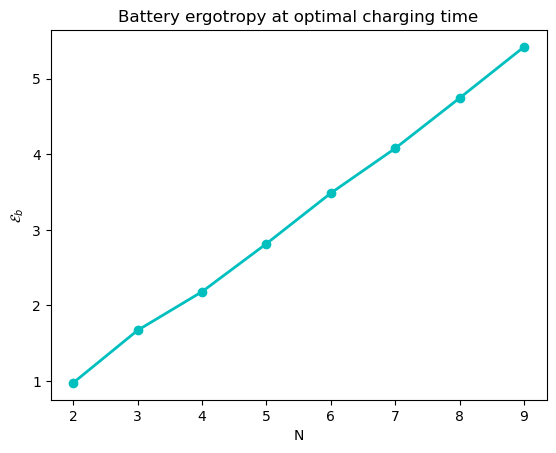

In [25]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt

############
# parameters
############

N_arr = np.arange(2, 10, 1)
nmax = 60
ω = 1.0
ω0 = 1.0
g = 1.0
tlist = np.arange(0.01, 2*np.pi, 0.0001)

#############################
# Tavis–Cummings Hamiltonian
#############################

def tavis_cummings(N, nmax, ω, ω0, g):

    a  = qt.destroy(nmax)
    Ic = qt.qeye(nmax)

    sp, sm, sz = qt.sigmap(), qt.sigmam(), qt.sigmaz()

    def embed(op, i):
        ops = [qt.qeye(2)]*N
        ops[i] = op
        return qt.tensor(ops)

    Sp = sum(embed(sp, i) for i in range(N))
    Sm = Sp.dag()
    Sz = 0.5 * sum(embed(sz, i) for i in range(N))

    IB = qt.tensor([qt.qeye(2)]*N)
    HB = Sz + 0.5 * N * IB

    H = (ω * qt.tensor(a.dag()*a, IB) + ω0 * qt.tensor(Ic, HB) + g * (qt.tensor(a, Sp) + qt.tensor(a.dag(), Sm)))
    return H, HB

##################
# Initial state
##################

def initial_state(N, nmax, state):

    if state == "coherent":
        psiA = qt.coherent(nmax, np.sqrt(N))
    elif state == "fock":
        psiA = qt.basis(nmax, N)

    psiB = qt.tensor([qt.basis(2, 1) for _ in range(N)])
    return qt.tensor(psiA, psiB)

#########################################
# optimal charging time τ (maximum power)
#########################################

τ_list = []

for N in N_arr:
    H, HB = tavis_cummings(N, nmax, ω, ω0, g)
    HB_full = qt.tensor(qt.qeye(nmax), HB)
    psi0 = initial_state(N, nmax, "fock")

    res = qt.sesolve(H, psi0, tlist, e_ops=HB_full)
    EB = np.array(res.expect[0])
    power = EB / tlist

    τ_list.append(tlist[np.argmax(power)])

###########################################
# Calculation of ergotropy and fluctuations
###########################################

E_ratio, E_ergo, E_var, F_ratio, FE_ratio = [], [], [], [], []

for i, N in enumerate(N_arr):

    τ = τ_list[i]
    
    H, HB = tavis_cummings(N, nmax, ω, ω0, g)
    
    psi0 = initial_state(N, nmax, "fock")

    res = qt.sesolve(H, psi0, [0, τ])
    
    rho_b = res.states[-1].proj().ptrace(list(range(1, N+1)))

    E_B = qt.expect(HB, rho_b)
    
    r_vals, r_vecs = rho_b.eigenstates()
    
    idx = np.argsort(r_vals)[::-1]
    r_vals = r_vals[idx]
    r_vecs = [r_vecs[i] for i in idx]
    
    # Passive Hamiltonian constructed in the passive state's eigenbasis
    
    e_vals, e_vecs = HB.eigenstates()
    
    H_passive = sum(e_vals[i] * r_vecs[i] * r_vecs[i].dag() for i in range(len(e_vals)))

    # Ergotropy operator defined w.r.t. passive Hamiltonian
    
    E_op = HB - H_passive
    
    E_B = qt.expect(HB, rho_b)
    
    E_erg = qt.expect(E_op, rho_b)

    ΔE2 = qt.expect(E_op**2, rho_b) - E_erg**2
    
    ΔE = np.sqrt(qt.expect(E_op**2, rho_b) - E_erg**2)

    Ratio = E_erg / E_B
    
    E_ergo.append(E_erg)

    E_var.append(ΔE2)
    
    E_ratio.append(Ratio)
    
    F_ratio.append(ΔE / E_erg)

    FE_ratio.append(ΔE / E_B)

    print(f"N={N:2d}, τ={τ:.4f}, Eb={E_B:.6f}, Ergotropy={E_erg:.6f}, erg/Eb={Ratio:.12f} Variance={ΔE2:.10e}")


###############################################################
# Plot of battery ergotropy at optimal charging for different N 
###############################################################

plt.plot(N_arr, E_ergo, 'o-', color='c', linewidth=2)
plt.xlabel("N")
plt.ylabel(r"$\mathcal{E}_b$")
plt.title("Battery ergotropy at optimal charging time")
plt.savefig("OP1")
plt.show()

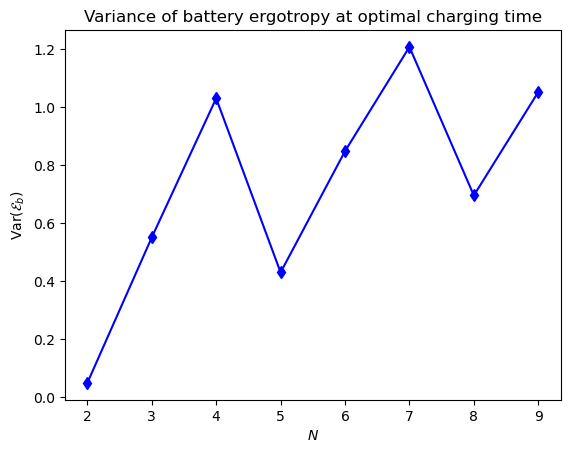

In [26]:
###########################################################################
# Plot of variance of battery ergotropy at optimal charging for different N 
###########################################################################

plt.figure()
plt.plot(N_arr, E_var, 'd-', color='b')
plt.xlabel(r"$N$")
plt.ylabel(r"$\mathrm{Var}(\mathcal{E}_b)$")
plt.title("Variance of battery ergotropy at optimal charging time")
plt.savefig("OP2")
plt.show()

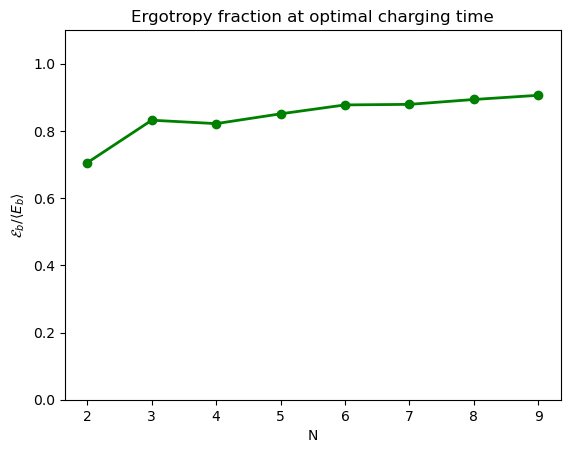

In [27]:
#############################################################
# Plot ergotropy fraction as a function of g for different N 
############################################################
    
plt.plot(N_arr, E_ratio, 'o-', color='g', linewidth=2)
plt.xlabel("N")
plt.ylabel(r"$\mathcal{E}_b / \langle E_b \rangle$")
plt.ylim(0,1.1)
plt.title("Ergotropy fraction at optimal charging time")
plt.savefig("OP3")
plt.show()

N= 2, τ=0.7796, Relative Fluctuation =0.227782210694, Relative Fluctuation with Eb =0.160703047828
N= 3, τ=0.6353, Relative Fluctuation =0.444290978486, Relative Fluctuation with Eb =0.369597298325
N= 4, τ=0.5526, Relative Fluctuation =0.465345264193, Relative Fluctuation with Eb =0.382387489316
N= 5, τ=0.4967, Relative Fluctuation =0.232831689537, Relative Fluctuation with Eb =0.198117312769
N= 6, τ=0.4556, Relative Fluctuation =0.264148680649, Relative Fluctuation with Eb =0.231764465884
N= 7, τ=0.4236, Relative Fluctuation =0.269387139980, Relative Fluctuation with Eb =0.236803048828
N= 8, τ=0.3977, Relative Fluctuation =0.175758258853, Relative Fluctuation with Eb =0.157051538734
N= 9, τ=0.3763, Relative Fluctuation =0.189166702157, Relative Fluctuation with Eb =0.171384940743


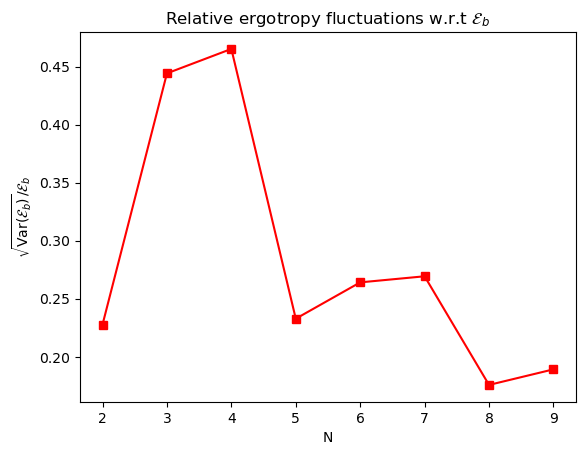

In [28]:
for idx, N in enumerate(N_arr):
    print(f"N={N:2d}, τ={τ_list[idx]:.4f}, Relative Fluctuation ={F_ratio[idx]:.12f}, Relative Fluctuation with Eb ={FE_ratio[idx]:.12f}")


######################################################
# Plot fluctuations as a function of g for different N 
######################################################

plt.plot(N_arr, F_ratio, 's-', color='r')
plt.xlabel("N")
plt.ylabel(r"$\sqrt{\mathrm{Var}(\mathcal{E}_b)}/\mathcal{E}_b$")
plt.title(r"Relative ergotropy fluctuations w.r.t $\mathcal{E}_b$")
plt.savefig("OP4")
plt.show()

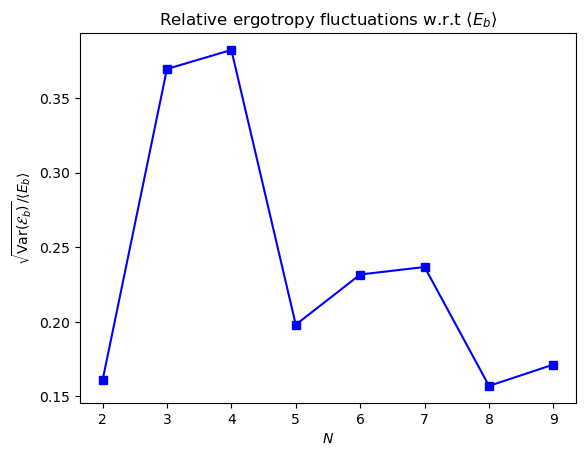

In [29]:
##########################################################################
# Plot fluctuations w.r.t battery energy as function of g for different N 
##########################################################################

plt.figure()
plt.plot(N_arr, FE_ratio, 's-', color='b')
plt.xlabel(r"$N$")
plt.ylabel(r"$\sqrt{\mathrm{Var}(\mathcal{E}_b)}/ \langle E_b \rangle$")
plt.title(r"Relative ergotropy fluctuations w.r.t $\langle E_b \rangle$")
plt.savefig("OP5")
plt.show()

In [30]:
# =========================
# Check ground state of HB
# =========================

evals, evecs = HB.eigenstates()

psi0_all = qt.tensor([qt.basis(2,0) for _ in range(N)])  # |0...0>
psi1_all = qt.tensor([qt.basis(2,1) for _ in range(N)])  # |1...1>

E0 = qt.expect(HB, psi0_all)
E1 = qt.expect(HB, psi1_all)

print(f"\nN = {N}")
print(f"Ground energy (from diagonalization): {evals[0]:.4f}")
print(f"Energy of |0...0>: {E0:.4f}")
print(f"Energy of |1...1>: {E1:.4f}")

print("Is |0...0> ground state?", np.isclose(E0, evals[0]))
print("Is |1...1> ground state?", np.isclose(E1, evals[0]))


N = 9
Ground energy (from diagonalization): 0.0000
Energy of |0...0>: 9.0000
Energy of |1...1>: 0.0000
Is |0...0> ground state? False
Is |1...1> ground state? True
